In [2]:
#import tidy all data csv file
import os
import pandas as pd
import numpy as np

tidy_all_data = pd.read_csv(os.path.join('..','..','data','processed','tidy_all_metrics.csv'))



In [3]:
tidy_all_data[tidy_all_data['Year']==2007].tail()

,Municipality_Name,Year,Metric,Value,Unit
126964,Warfield,2007,Log_Transport_Polluting_Emissions_Factor,0.000154,Log_CO2_per_km_travelled
126965,West Vancouver,2007,Log_Transport_Polluting_Emissions_Factor,0.000147,Log_CO2_per_km_travelled
126966,Whistler,2007,Log_Transport_Polluting_Emissions_Factor,0.000168,Log_CO2_per_km_travelled
126967,White Rock,2007,Log_Transport_Polluting_Emissions_Factor,0.000147,Log_CO2_per_km_travelled
126968,Williams Lake,2007,Log_Transport_Polluting_Emissions_Factor,0.000212,Log_CO2_per_km_travelled


In [4]:
# choose reference year and metric list (edit to taste)
REFERENCE_YEAR = 2021


decomposition_analysis_features = [
]

decoupling_analysis_features = [
]

share_change_analysis_features = [
]

just_transition_analysis_features = [
    
] #what's great of including this here is that looking at whether labour force and education decreased in an area while 
# emissions decreased goes against the justice framework. We want labour force, education, and wellbeing in general to stay good while we reduce emissions!!!


all_key_features = [
    # Context
    'Remoteness',
    'Latitude',
    'Longitude',
    
    #Climate action
    'Climate_Action_N_Barriers',
    'Climate_Action_Score',
    
    # Socio-economic baseline
    'Log_Population',
    'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
    
    # Low-emissions energy shares baseline
    'Utility_Residential_Electricity_Energy_Share',
    'Utility_CSMI_Electricity_Energy_Share',
    'Transportation_Low_Emission_Vehicle_km_Travelled_Share',
    
    # Economic structure baseline
    'Utility_CSMI_Total_Energy_Share', #this is share on total utility enery, not including tranport

    # Energy transition trajectories
    'Residential_Electricity_Share_Percent_Change',
    'CSMI_Electricity_Share_Percent_Change',
    'Transport_Low_Emission_Share_Percent_Change',
    
    # Economic transition trajectories
    'CSMI_Total_Energy_Share_Percent_Change',
    
    # Per capita values for 2021
    'Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Log_Residential_Electricity_Per_Capita',
    'Log_Residential_Polluting_Per_Capita',
    'Log_CSMI_Electricity_Per_Capita' ,
    'Log_CSMI_Polluting_Per_Capita' ,

    # Per capita changes 2007-2021 (pop from 2006 as a proxy for 2007)
    'Log_Diff_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    'Log_Diff_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Log_Diff_Residential_Electricity_Per_Capita',
    'Log_Diff_Residential_Polluting_Per_Capita',
    'Log_Diff_CSMI_Electricity_Per_Capita',
    'Log_Diff_CSMI_Polluting_Per_Capita',
    
    # Emission factor end year levels
    #'Log_Utility_Residential_Electricity_Emissions_Factor', #-> everyone has the same emissions factor because everyone is connected to the same grid
    'Log_Utility_Residential_Polluting_Emissions_Factor',
    #'Log_Utility_CSMI_Electricity_Emissions_Factor', #-> everyone has the same emissions factor because everyone is connected to the same grid
    #'Log_Utility_CSMI_Polluting_Emissions_Factor', #-> not estimated due to zero divided by zero
    'Log_Transport_Low_Emission_Emissions_Factor',
    'Log_Transport_Polluting_Emissions_Factor',
    
    # Emission factor changes 2007-2021
    #'Log_Diff_Utility_Residential_Electricity_Emissions_Factor', #-> everyone has the same difference because everyone is connected to the same grid 
    'Log_Diff_Utility_Residential_Polluting_Emissions_Factor',
    #'Log_Diff_Utility_CSMI_Electricity_Emissions_Factor', -> #everyone has the same difference because everyone is connected to the same grid
    #'Log_Diff_Utility_CSMI_Polluting_Emissions_Factor', -> not estimated due to zero divided by zero
    'Log_Diff_Transport_Low_Emission_Emissions_Factor',
    'Log_Diff_Transport_Polluting_Emissions_Factor'
]

low_emission_transport_policy = [
    'Remoteness', #more remote communities may need to travel further distances and have more range anxiety with EVs (but hybrids have better milage though)
    'Income', # income affects the ability to purchase EVs or hybrids since their upfront cost can be higher
    'Income_Percent_Change', # incomes trends (e.g. declines) could lead people to prioritize purchasing other things instead of EVs/hybrids
    'Housing', # housing quality and quantity affects one's ability to charge their EV (apartments have more difficulty installing chargers, and housing needing maintenance may not have proper infrastructure to install chargers either)
    'Housing_Percent_Change', # housing quality/quantity trends
    'Log_Residential_Electricity_Per_Capita', # home electrification level important as people often charge EVs at home
    'Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita', # current levels of EVs/hybrids -> social signaling of EVs/Hybrid vehicles could create cultures of acceptance of EV/hybrids
    # change to private polluting vehicle km travelled
    # 'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita', # current levels of polluting vehicles -> social signaling of polluting vehicles could create cultures of rejection of EV/hybrids. Furthermore, stock of polluting vehicles can get moved around as people sell second hand cars
    'Log_Diff_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita', # is the number of hybdrids/EVs already increasing in this place?
    # change to private polluting vehicle
    #'Log_Diff_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita', # is the number of polluting vehicles increasing/decreasing?
    'Log_Transport_Low_Emission_Emissions_Factor', # is the numher of EVs higher than hybrids?
    'Log_Transport_Polluting_Emissions_Factor', # how polluting are the polluting vehicles?
    'Log_Diff_Transport_Low_Emission_Emissions_Factor', # are EVs outpacing hybrids over time?
    #change to private polluting vehicle
    #'Log_Diff_Transport_Polluting_Emissions_Factor' # are very polluting vehicles outpacing midly polluting vehicles over time?
]

residential_electrification_policy = [
    'Latitude', #proxy for different temperatures north/south
    'Income', #income affects ability to purchase heatpumps
    'Housing', #housing quality and availability affects ability to install heatpumps
    'Education', #education may affect ability to navigate installing heatpumps and also signal more progressive communities that are more likely to adopt heatpumps
    'Labour_Force', #labour force affects ability to do renovations to install heatpumps 
    'Log_Population',  
    'Remoteness',  
        
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
    
    #Climate action
    'Climate_Action_N_Barriers',
    'Climate_Action_Score',
    
    #'Log_Residential_Electricity_Per_Capita', # Electricity use at homes important as heatpumps are electric
    #'Log_Residential_Polluting_Per_Capita', # Polluting energy use at homes important to signal places needing to transition
    #'Log_Diff_Residential_Electricity_Per_Capita', # Electricity changes at homes important as heatpumps are electric
    #'Log_Diff_Residential_Polluting_Per_Capita',  # Polluting energy changes use at homes important to signal places already transitioning or starting to use even more polluting energy
    
    #If we want to use aggregate per capita energy and emissions
    'Log_Utility_Residential_Emissions_Factor', # checked on tidy_all_data.csv that this is different across communities, varying from ~0.006 to ~0.017, so not sure why its the same value when calculating the means
    'Log_Residential_Total_Energy_Per_Capita', 
    'Log_Diff_Utility_Residential_Emissions_Factor',
    'Log_Diff_Residential_Total_Energy_Per_Capita',
]


industrial_policy_features = [
    # Socio-economic baseline
    'Log_Population',
    'Income', 'Education', 'Housing', 'Labour_Force',
    
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
    
    'Utility_CSMI_Electricity_Energy_Share',
    
    'Utility_CSMI_Total_Energy_Share', #this is share on total utility enery, not including tranport
    
    'CSMI_Electricity_Share_Percent_Change',
    
    'CSMI_Total_Energy_Share_Percent_Change',
    
    'Log_Diff_CSMI_Electricity_Per_Capita',
    'Log_Diff_CSMI_Polluting_Per_Capita',
    'Log_CSMI_Electricity_Per_Capita' ,
    'Log_CSMI_Polluting_Per_Capita',
    
    #if we want to use the aggregate per capita energy
    'Log_CSMI_Total_Energy_Per_Capita',
    'Log_Diff_CSMI_Total_Energy_Per_Capita',
    'Log_Utility_CSMI_Emissions_Factor',
    'Log_Diff_Utility_CSMI_Emissions_Factor'
]

non_unimodal_features = [
    
    ]


socio_economic_political_context = [
    #Climate action
    'Climate_Action_N_Barriers',
    'Climate_Action_Score',
    
    # Socio-economic baseline
    'Log_Population',
    'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Socio-economic trajectories
    'Income_Percent_Change', 'Education_Percent_Change', 
    'Housing_Percent_Change', 'Labour_Percent_Change', 
    'Log_Population_Change_2006_2021',
]


wellbeing_features = [
    # Wellbeing baseline
    'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Wellbeing trajectories
    'income_percent_change', 'education_percent_change', 
    'housing_percent_change', 'labour_percent_change', 
    'population_percent_change'
    ]

climate_action_summary_features = [
     #Climate action
    'Climate_Action_N_Barriers',
    'Climate_Action_Score'
    ]

#variables that won't change over time (remoteness could change over decades or centuries or with a large intervention, but lat,lon won't change)
structural = [
    'Remoteness', 
    'Latitude', 
    'Longitude',
    ]

features_visual_inspection =[
    'Remoteness',
    'Latitude',
    'Utility_Residential_Electricity_Energy_Share',
    'Log_CSMI_Polluting_Per_Capita',
]

features_to_use = residential_electrification_policy
# residential_electrification_policy
# low_emission_transport_policy


# build wide feature matrix for REFERENCE_YEAR
df_base_year = tidy_all_data.loc[tidy_all_data['Year'] == REFERENCE_YEAR, ['Municipality_Name','Metric','Value']].copy()
# Find duplicates
duplicates = df_base_year[df_base_year.duplicated(subset=['Municipality_Name', 'Metric'], keep=False)]
print(f"Found {len(duplicates)} duplicate rows:")
display(duplicates.sort_values(['Municipality_Name', 'Metric']))

df_wide_base_year = df_base_year.pivot(index='Municipality_Name', columns='Metric', values='Value')
# ensure chosen features are present, add missing as NaN
for f in features_to_use:
    if f not in df_wide_base_year.columns:
        df_wide_base_year[f] = np.nan

# select only desired columns and drop rows with no data at all
X = df_wide_base_year[features_to_use].copy()

# diagnostic: find missing values BEFORE scaling/PCA (PCA/Scaler do not accept NaN)
nan_counts = X.isna().sum()
if nan_counts.sum() > 0:
    print("Missing values present. Counts per feature:\n", nan_counts[nan_counts > 0])
    nan_rows = X[X.isna().any(axis=1)]
    print("\nCommunities with missing data (total {}):".format(len(nan_rows)))
    for idx, row in nan_rows.iterrows():
        missing_feats = row[row.isna()].index.tolist()
        print(f" - {idx}: missing {missing_feats}")
    # show some raw tidy rows for the first few affected communities to investigate source
    sample_comm = list(nan_rows.index)[:8]
    print("\nSample raw tidy_all_data rows for inspection:")
    display(tidy_all_data[tidy_all_data['Municipality_Name'].isin(sample_comm)].sort_values(['Municipality_Name','Year','Metric']).tail(100))
else:
    print("No missing values found in X.")


Found 0 duplicate rows:


,Municipality_Name,Metric,Value


No missing values found in X.


In [5]:
df_base_year.head()

,Municipality_Name,Metric,Value
22,Abbotsford,Utility_Residential_Polluting_Energy,2.814366e+06
23,Abbotsford,Utility_CSMI_Polluting_Energy,5.634019e+06
46,Alert Bay,Utility_Residential_Polluting_Energy,5.090462e+03
47,Alert Bay,Utility_CSMI_Polluting_Energy,0.000000e+00
70,Anmore,Utility_Residential_Polluting_Energy,1.072483e+05


In [6]:
df_base_year[df_base_year['Metric'] == 'Log_Utility_Residential_Emissions_Factor']

,Municipality_Name,Metric,Value
125793,Abbotsford,Log_Utility_Residential_Emissions_Factor,0.013136
125794,Alert Bay,Log_Utility_Residential_Emissions_Factor,0.006684
125795,Anmore,Log_Utility_Residential_Emissions_Factor,0.014853
125796,Armstrong,Log_Utility_Residential_Emissions_Factor,0.014273
125797,Ashcroft,Log_Utility_Residential_Emissions_Factor,0.014270
...,...,...,...
125935,Warfield,Log_Utility_Residential_Emissions_Factor,0.015476
125936,West Vancouver,Log_Utility_Residential_Emissions_Factor,0.015301
125937,Whistler,Log_Utility_Residential_Emissions_Factor,0.008204
125938,White Rock,Log_Utility_Residential_Emissions_Factor,0.012365


In [7]:
# clustering municipalities based on PCA of selected metrics

# --- PCA + clustering pipeline (add / run in a new cell) ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

standardize = True
#select which X to use for clustering (scaled or original)
if standardize:
    # Standardize (use X for the pipeline)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_for_clustering = X_scaled.copy()
else: 
    X_for_clustering = X.copy()


In [8]:

from diptest import diptest

multimodal_features = []
for col in X.columns:
    dip, p = diptest(X[col].values)
    if p < 0.1:
        multimodal_features.append(col)
        print(f"{col}: p={p:.4f} (non-normal)")
        


Income: p=0.0065 (non-normal)
Housing: p=0.0000 (non-normal)
Education: p=0.0659 (non-normal)
Labour_Force: p=0.0001 (non-normal)
Remoteness: p=0.0002 (non-normal)
Housing_Percent_Change: p=0.0000 (non-normal)
Labour_Percent_Change: p=0.0000 (non-normal)
Climate_Action_N_Barriers: p=0.0000 (non-normal)
Climate_Action_Score: p=0.0000 (non-normal)


In [9]:
multimodal_features = []
num_features = X_scaled.shape[1]
for i in range (1, num_features):
    dip, p = diptest(X_scaled[:,i])
    if p < 0.1:
        multimodal_features.append(col)
        print(f"{col}: p={p:.4f} (non-normal)")

Log_Diff_Residential_Total_Energy_Per_Capita: p=0.0065 (non-normal)
Log_Diff_Residential_Total_Energy_Per_Capita: p=0.0000 (non-normal)
Log_Diff_Residential_Total_Energy_Per_Capita: p=0.0659 (non-normal)
Log_Diff_Residential_Total_Energy_Per_Capita: p=0.0001 (non-normal)
Log_Diff_Residential_Total_Energy_Per_Capita: p=0.0002 (non-normal)
Log_Diff_Residential_Total_Energy_Per_Capita: p=0.0000 (non-normal)
Log_Diff_Residential_Total_Energy_Per_Capita: p=0.0000 (non-normal)
Log_Diff_Residential_Total_Energy_Per_Capita: p=0.0000 (non-normal)
Log_Diff_Residential_Total_Energy_Per_Capita: p=0.0000 (non-normal)


In [10]:
# Correlation matrix
corr_matrix = X.corr()#.abs()

# Find pairs with correlation > 0.7
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.7 or corr_matrix.iloc[i, j] < -0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Highly correlated pairs (keep one, drop other):")
for v1, v2, corr in high_corr_pairs:
    print(f"  {v1} <-> {v2}: {corr:.2f}")

Highly correlated pairs (keep one, drop other):
  Log_Population <-> Remoteness: -0.70


In [11]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def hopkins_statistic(X, sample_size=0.5):
    n = len(X)
    m = int(n * sample_size)
    
    # Random points from data space
    X_uniform = np.random.uniform(X.min(axis=0), X.max(axis=0), (m, X.shape[1]))
    
    # Random sample from actual data
    random_indices = np.random.choice(n, m, replace=False)
    X_sample = X[random_indices]
    
    # Nearest neighbor distances
    nn = NearestNeighbors(n_neighbors=2)
    nn.fit(X)
    
    u_dist = nn.kneighbors(X_uniform, return_distance=True)[0][:, 1]
    w_dist = nn.kneighbors(X_sample, return_distance=True)[0][:, 1]
    
    H = u_dist.sum() / (u_dist.sum() + w_dist.sum())
    return H

H = hopkins_statistic(X_for_clustering)#(X_scaled)
print(f"Hopkins statistic: {H:.3f}")

Hopkins statistic: 0.722


In [12]:
from sklearn.cluster import KMeans
import numpy as np

def gap_statistic(X, k_range=range(1, 10), n_refs=10):
    gaps = []
    for k in k_range:
        # Your data's within-cluster dispersion
        if k == 1:
            Wk = np.sum((X - X.mean(axis=0))**2)
        else:
            km = KMeans(n_clusters=k, random_state=42)
            km.fit(X)
            Wk = km.inertia_
        
        # Reference (random uniform) dispersion
        ref_disps = []
        for _ in range(n_refs):
            X_random = np.random.uniform(X.min(axis=0), X.max(axis=0), X.shape)
            if k == 1:
                ref_disps.append(np.sum((X_random - X_random.mean(axis=0))**2))
            else:
                km_ref = KMeans(n_clusters=k, random_state=42)
                km_ref.fit(X_random)
                ref_disps.append(km_ref.inertia_)
        
        gap = np.mean(np.log(ref_disps)) - np.log(Wk)
        gaps.append(gap)
    
    return list(k_range), gaps

ks, gaps = gap_statistic(X_for_clustering)
print("If gap peaks at k=1 or stays flat, no clustering may be justified.")
for k, gap in zip(ks, gaps):
    print(f"k={k}: gap={gap:.3f}")

If gap peaks at k=1 or stays flat, no clustering may be justified.
k=1: gap=1.121
k=2: gap=1.228
k=3: gap=1.283
k=4: gap=1.251
k=5: gap=1.247
k=6: gap=1.322
k=7: gap=1.348
k=8: gap=1.371
k=9: gap=1.367


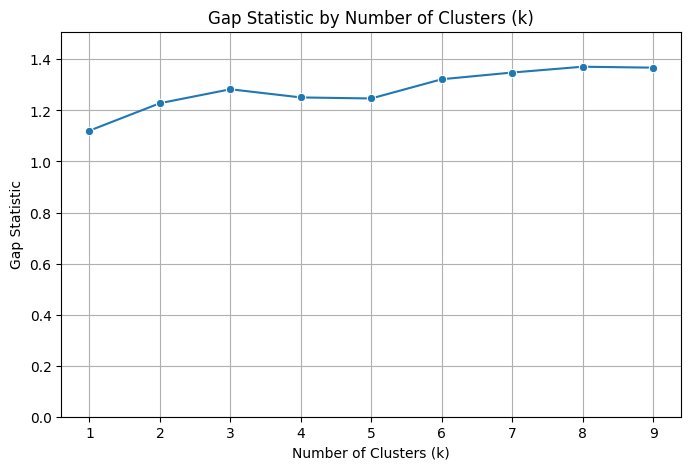

In [13]:
#plot gap score vs k
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.lineplot(x=ks, y=gaps, marker='o')
plt.title('Gap Statistic by Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Gap Statistic')
plt.ylim(0.0, max(gaps)*1.1)
plt.xticks(ks)
plt.grid()
plt.show()

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mstats

# choose number of clusters with silhouette (k=2..8)
best_k, best_score = None, -1
scores = {}
all_labels = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = km.fit_predict(X_for_clustering)
    all_labels[k] = labels
    score = silhouette_score(X_for_clustering, labels) #(X_for_clustering, labels)
    scores[k] = score
    if score > best_score:
        best_score = score
        best_k = k
print("Best k:", best_k, "score:", best_score)

print("Silhouette scores by k:", scores)

# Fit final KMeans on PCA space
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=100)
labels_final = kmeans_final.fit_predict(X_for_clustering)

# assemble results dataframe and save
clusters_df = pd.DataFrame({
    'Municipality_Name': X.index,
    'Cluster': labels_final
}).set_index('Municipality_Name')

# merge back some original features for inspection
clustered = X.merge(clusters_df, left_index=True, right_index=True)

# save CSV
clustered.reset_index().to_csv(os.path.join('..','..','data','processed','municipality_clusters_baseline2021.csv'), index=False)

Best k: 2 score: 0.19427691641086706
Silhouette scores by k: {2: np.float64(0.19427691641086706), 3: np.float64(0.15739846905989693), 4: np.float64(0.12702603651149058), 5: np.float64(0.13430433289445665), 6: np.float64(0.13373873636746922), 7: np.float64(0.13749950335053207), 8: np.float64(0.13194874433887763), 9: np.float64(0.09647238240030685)}


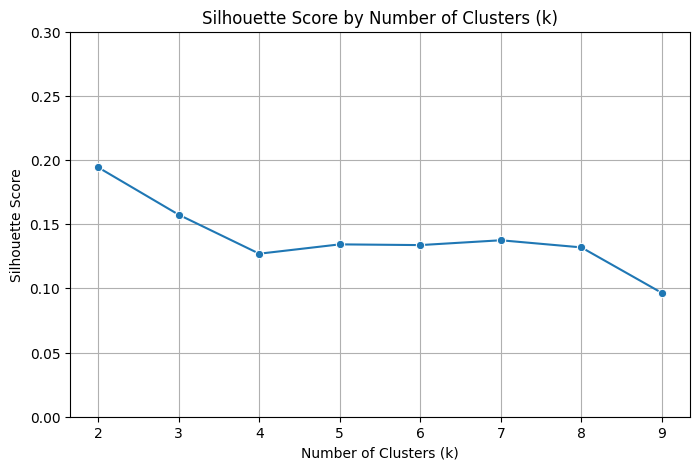

In [15]:
#plot silhouette score vs k
plt.figure(figsize=(8,5))
sns.lineplot(x=list(scores.keys()), y=list(scores.values()), marker='o')
plt.title('Silhouette Score by Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
#make y axis start at 0.0 and end at 0.5
plt.ylim(0.0, 0.3)
plt.xticks(list(scores.keys()))
plt.grid()
plt.show()


In [86]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mstats


manual_k = 9
# Fit final KMeans on best k or manual k
kmeans_final = KMeans(n_clusters=manual_k, random_state=42, n_init=100)
labels_final = kmeans_final.fit_predict(X_for_clustering)

# assemble results dataframe and save
clusters_df = pd.DataFrame({
    'Municipality_Name': X.index,
    'Cluster': labels_final
}).set_index('Municipality_Name')

# merge back some original features for inspection
clustered = X.merge(clusters_df, left_index=True, right_index=True)

# save CSV
clustered.reset_index().to_csv(os.path.join('..','..','data','processed','municipality_clusters_baseline2021.csv'), index=False)

In [87]:
dip, p = diptest(X_for_clustering[:,1])
print(f"diptest for original p={p:.4f}")

diptest for original p=0.0065


In [88]:
# Quick diagnostics: which input variables drive PCs and clusters
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from IPython.display import display


# PCA loadings (full PCA on standardized inputs)
pca_full = PCA().fit(X_for_clustering)
loadings = pd.DataFrame(pca_full.components_.T,
                        index=X.columns,
                        columns=[f'PC{i+1}' for i in range(pca_full.components_.shape[0])])
explained = pd.Series(pca_full.explained_variance_ratio_, index=loadings.columns)

# Find variables with max absolute loading < 0.2 across PC1-PC4
max_loadings = loadings.iloc[:, :4].abs().max(axis=1)
low_contributors = max_loadings[max_loadings < 0.2].index.tolist()
print("Consider removing:", low_contributors)

print("Explained variance (first 6 PCs):")
print(explained.head(6).round(3))

print("\nTop contributors to PC1 (absolute loading):")
display(loadings['PC1'].abs().sort_values(ascending=False).head(10))

print("\nTop contributors to PC2 (absolute loading):")
display(loadings['PC2'].abs().sort_values(ascending=False).head(10))

print("\nTop contributors to PC3 (absolute loading):")
display(loadings['PC3'].abs().sort_values(ascending=False).head(10))


Consider removing: []
Explained variance (first 6 PCs):
PC1    0.276
PC2    0.141
PC3    0.097
PC4    0.079
PC5    0.075
PC6    0.064
dtype: float64

Top contributors to PC1 (absolute loading):


Metric
Remoteness                         0.375986
Education                          0.368154
Log_Population                     0.360174
Climate_Action_Score               0.327687
Log_Population_Change_2006_2021    0.312420
Latitude                           0.298869
Labour_Force                       0.272670
Income                             0.222671
Housing                            0.203741
Climate_Action_N_Barriers          0.203511
Name: PC1, dtype: float64


Top contributors to PC2 (absolute loading):


Metric
Log_Diff_Utility_Residential_Emissions_Factor    0.505798
Log_Utility_Residential_Emissions_Factor         0.483418
Log_Residential_Total_Energy_Per_Capita          0.468389
Log_Diff_Residential_Total_Energy_Per_Capita     0.380669
Income                                           0.209146
Housing                                          0.198465
Income_Percent_Change                            0.150359
Climate_Action_N_Barriers                        0.101122
Latitude                                         0.095201
Log_Population_Change_2006_2021                  0.073319
Name: PC2, dtype: float64


Top contributors to PC3 (absolute loading):


Metric
Education_Percent_Change                         0.463922
Income_Percent_Change                            0.452663
Housing_Percent_Change                           0.443419
Labour_Percent_Change                            0.331135
Income                                           0.289534
Log_Diff_Utility_Residential_Emissions_Factor    0.213674
Housing                                          0.210152
Latitude                                         0.180008
Log_Utility_Residential_Emissions_Factor         0.147229
Log_Population_Change_2006_2021                  0.132175
Name: PC3, dtype: float64

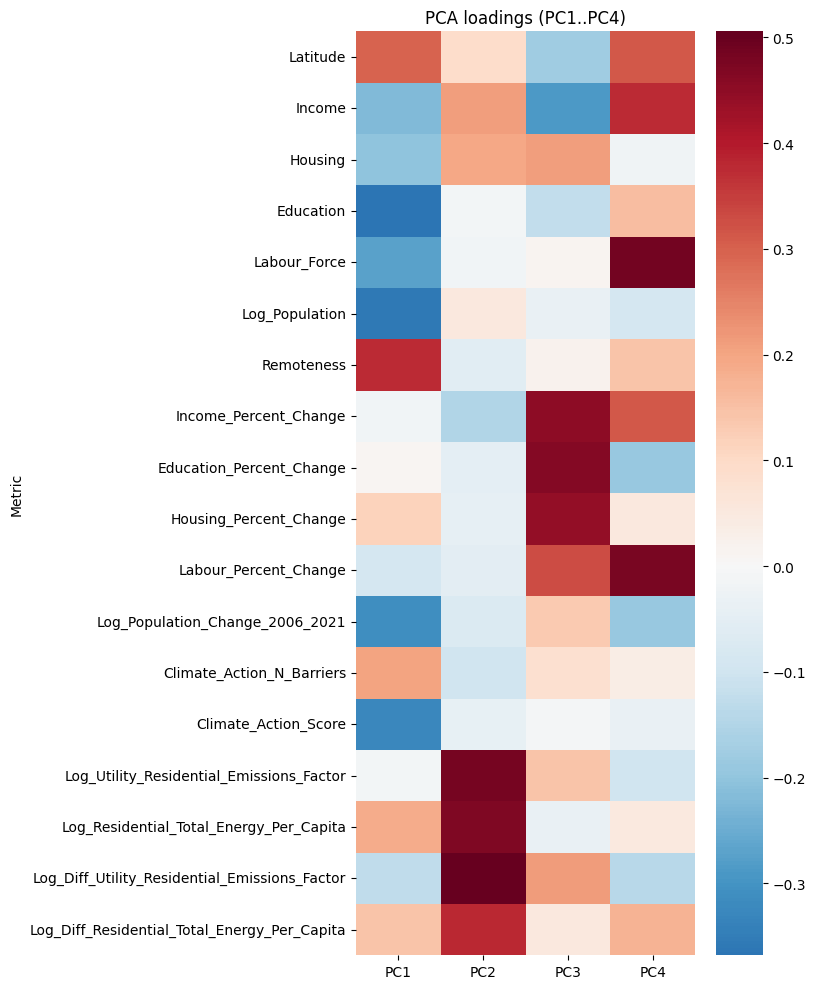

In [89]:
# Heatmap of loadings for first 4 PCs
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,10))
sns.heatmap(loadings.iloc[:, :4], cmap='RdBu_r', center=0, annot=False)
plt.title('PCA loadings (PC1..PC4)')
plt.tight_layout()
plt.show()

In [90]:

# Quick summary per cluster
display(clustered.groupby('Cluster').mean().round(4))
#save means in a csv
clustered.groupby('Cluster').mean().round(4).to_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_means.csv'))

#display standard deviation per cluster
display(clustered.groupby('Cluster').std().round(4))
clustered.groupby('Cluster').std().round(4).to_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_std.csv'))

,Latitude,Income,Housing,Education,Labour_Force,Log_Population,Remoteness,Income_Percent_Change,Education_Percent_Change,Housing_Percent_Change,Labour_Percent_Change,Log_Population_Change_2006_2021,Climate_Action_N_Barriers,Climate_Action_Score,Log_Utility_Residential_Emissions_Factor,Log_Residential_Total_Energy_Per_Capita,Log_Diff_Utility_Residential_Emissions_Factor,Log_Diff_Residential_Total_Energy_Per_Capita
Cluster,,,,,,,,,,,,,,,,,,
0,49.1385,82.0400,96.4000,68.7600,87.0400,4.2990,0.1874,10.7210,11.1848,-0.0756,-0.7897,0.1044,3.4400,4.0800,0.0094,1.5274,-0.0019,-0.0611
1,54.5094,82.0714,94.2857,58.7143,84.5714,3.5363,0.4433,8.0404,7.6620,-0.5005,-2.2368,-0.0172,4.0000,1.1429,0.0149,1.7492,-0.0013,-0.0091
2,51.4699,75.5455,93.6364,56.2727,79.2727,3.0848,0.4279,11.1201,23.6407,5.3368,-5.7775,-0.0003,4.3636,0.9091,0.0128,1.6866,-0.0014,-0.0198
3,53.6561,79.1000,89.9000,56.7000,81.5000,2.8742,0.5590,12.0647,4.1352,-1.0707,-2.8173,-0.0433,4.5000,0.8000,0.0077,1.6182,-0.0046,-0.0433
4,50.0689,80.2826,95.8696,64.8478,85.6739,3.7915,0.3272,11.7878,12.7739,0.3851,-0.0498,0.0698,4.0652,1.8261,0.0132,1.6604,-0.0011,-0.0504
5,50.1440,76.7500,94.5000,61.7500,83.7500,3.3298,0.3971,10.1769,12.1505,1.8778,-0.3262,0.0098,4.4375,1.3750,0.0060,1.5544,-0.0036,-0.0550
6,49.1444,83.6875,94.0625,74.0625,87.4375,5.0714,0.1015,10.7475,11.2506,-0.9170,-0.9947,0.0952,3.2500,4.4375,0.0124,1.4912,-0.0019,-0.0769
7,49.2496,95.2500,96.1250,79.6250,86.8750,3.7643,0.1236,6.9102,5.3166,0.5621,-3.5614,0.0631,3.8750,2.1250,0.0099,1.7475,-0.0014,-0.0356
8,54.6967,77.0000,93.0000,66.0000,87.0000,3.1685,0.4731,10.0000,13.7931,0.0000,1.1628,0.0562,5.0000,1.0000,0.0058,1.3212,-0.0101,-0.3412


,Latitude,Income,Housing,Education,Labour_Force,Log_Population,Remoteness,Income_Percent_Change,Education_Percent_Change,Housing_Percent_Change,Labour_Percent_Change,Log_Population_Change_2006_2021,Climate_Action_N_Barriers,Climate_Action_Score,Log_Utility_Residential_Emissions_Factor,Log_Residential_Total_Energy_Per_Capita,Log_Diff_Utility_Residential_Emissions_Factor,Log_Diff_Residential_Total_Energy_Per_Capita
Cluster,,,,,,,,,,,,,,,,,,
0,0.6215,2.8792,0.9574,3.2696,2.3180,0.4752,0.0631,2.6407,4.4519,1.1179,1.6010,0.0670,0.7681,0.9092,0.0032,0.0623,0.0006,0.0254
1,1.6375,3.0500,2.0164,2.4939,2.1381,0.4567,0.0468,4.8238,4.0882,2.5229,4.5548,0.0577,0.7845,1.0271,0.0014,0.0808,0.0006,0.0513
2,2.1082,4.2512,2.0627,3.9266,5.4054,0.3284,0.1026,6.5826,14.4843,4.1865,5.5448,0.0484,0.6742,0.9439,0.0030,0.0590,0.0010,0.0415
3,1.8301,3.7550,2.6013,6.6005,6.3114,0.4540,0.0802,4.4522,14.4365,3.9520,7.0898,0.0435,0.5270,0.7888,0.0025,0.0786,0.0011,0.0190
4,1.4423,3.3043,1.1853,5.2152,2.5565,0.4478,0.0948,3.2875,4.5223,1.8622,2.6254,0.0525,0.8274,1.2876,0.0022,0.0747,0.0008,0.0344
5,1.0584,3.8902,1.5055,5.5197,3.8730,0.4150,0.1406,3.4273,7.1410,2.8789,2.4861,0.0430,0.7274,1.2583,0.0020,0.0527,0.0008,0.0395
6,0.3113,4.3316,1.5262,4.7675,1.8608,0.3862,0.0323,2.1111,3.1572,1.0871,0.9149,0.0471,0.7746,0.8921,0.0021,0.0751,0.0007,0.0207
7,0.5153,4.1318,1.4577,3.1595,3.0443,0.6192,0.0403,5.5719,2.0139,2.2281,3.5658,0.0645,0.8345,1.7269,0.0046,0.1270,0.0012,0.0403
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


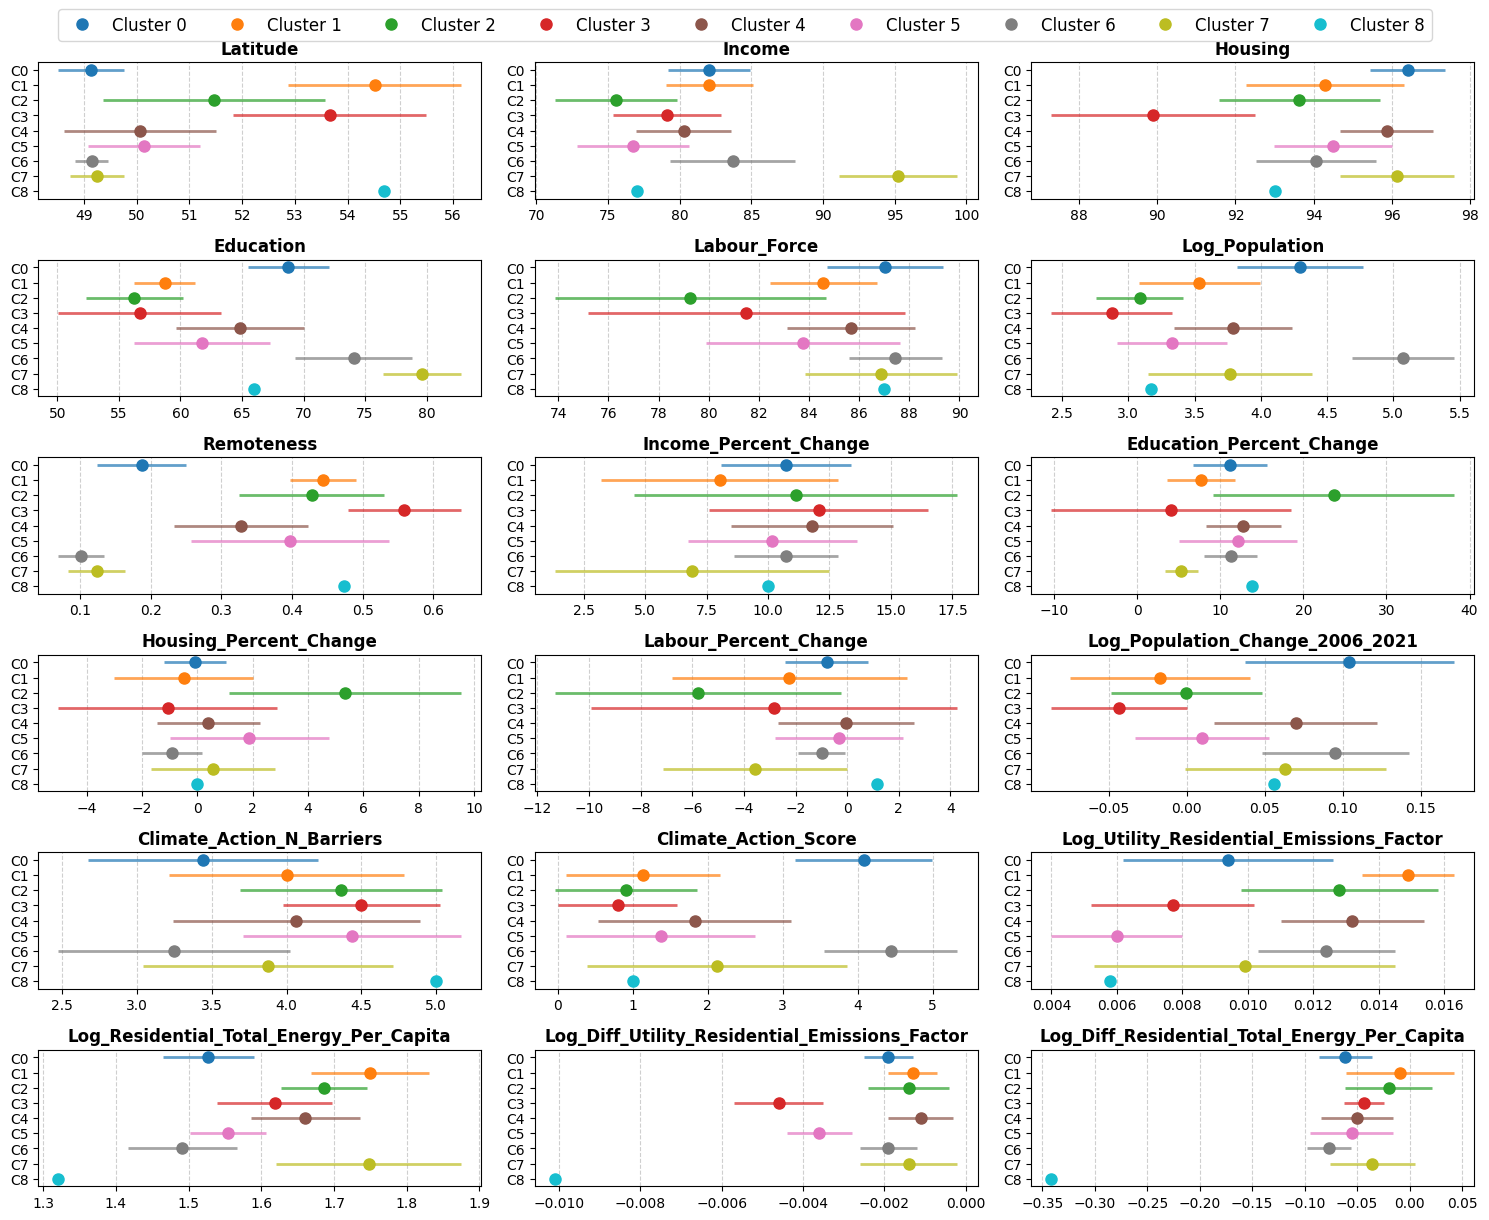

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
means_df = pd.read_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_means.csv'))
stds_df = pd.read_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_std.csv'))

# 2. Extract features and cluster labels
# We exclude the 'Cluster' column because it's our y-axis category, not a feature
features = [col for col in means_df.columns if col != 'Cluster']
n_features = len(features)
clusters = means_df['Cluster'].values

# 3. Calculate grid size for the subplots
cols = 3
# Automatically calculate how many rows are needed for 18 features (18/3 = 6 rows)
rows = int(np.ceil(n_features / cols))

# 4. Create the figure and axes
# figsize determines the width and height of the whole image. Adjust as needed!
fig, axes = plt.subplots(rows, cols, figsize=(15, 1*best_k*rows))
#fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Create a color map so each cluster has a distinct color
colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

# 5. Loop through each feature and plot it
for i, feature in enumerate(features):
    ax = axes[i]
    
    # Extract the arrays of means and standard deviations for the current feature
    f_means = means_df[feature].values
    f_stds = stds_df[feature].values
    
    # Plot the dot and whisker for each cluster
    for j, cluster in enumerate(clusters):
        # Plot the horizontal whisker (mean - std to mean + std)
        ax.hlines(y=cluster, 
                  xmin=f_means[j] - f_stds[j], 
                  xmax=f_means[j] + f_stds[j], 
                  color=colors[j], linewidth=2, alpha=0.7)
                  
        # Plot the dot (the mean)
        ax.plot(f_means[j], cluster, 'o', color=colors[j], markersize=8, 
                label=f'Cluster {int(cluster)}' if i==0 else "")
        
    # Formatting for the specific subplot
    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_yticks(clusters)
    ax.set_yticklabels([f'C{int(c)}' for c in clusters])
    ax.set_ylim(min(clusters)-0.5, max(clusters)+0.5) # Add some padding around the clusters
    ax.invert_yaxis()  # Put Cluster 0 at the top, Cluster 2 at the bottom
    ax.grid(True, axis='x', linestyle='--', alpha=0.6) # Vertical grid lines for readability

# 6. Clean up empty subplots
# If your features aren't a perfect multiple of the columns, hide the extra blank plots
for k in range(n_features, len(axes)):
    fig.delaxes(axes[k])

# 7. Add a single master legend at the very top of the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(clusters), fontsize=12)

# 8. Adjust layout and save
plt.tight_layout()
plt.savefig('faceted_dot_whisker.png', bbox_inches='tight', dpi=300)
plt.show() # Uncomment this if you are running in a Jupyter Notebook to see it inline

In [92]:
singleton_label = 6# whichever cluster has 1 member
singleton_idx = np.where(labels_final == singleton_label)[0]
print(X.iloc[singleton_idx])

Metric                     Latitude  Income  Housing  Education  Labour_Force  \
Municipality_Name                                                               
Abbotsford                49.052222    77.0     93.0       63.0          87.0   
Burnaby                   49.242778    81.0     92.0       75.0          85.0   
Coquitlam                 49.284167    81.0     94.0       76.0          86.0   
Delta                     49.084722    83.0     94.0       70.0          88.0   
Langley Township          49.120278    83.0     96.0       69.0          89.0   
New Westminster           49.206667    83.0     92.0       74.0          88.0   
North Vancouver City      49.320556    87.0     94.0       79.0          89.0   
North Vancouver District  49.336111    93.0     95.0       81.0          88.0   
Port Coquitlam            49.261944    82.0     95.0       71.0          88.0   
Port Moody                49.282222    89.0     96.0       79.0          89.0   
Richmond                  49

In [93]:
#calculate mean and std dev for all features of munis within each cluster, even the ones not used in clustering
# Pivot tidy_all_data to wide: municipalities × features
df_wide = tidy_all_data.pivot_table(
    index='Municipality_Name',
    columns='Metric',
    values='Value',
    aggfunc='first'  # in case of duplicates
)

# Add cluster labels (merge clusters_df into df_wide)
df_wide = df_wide.merge(clusters_df, left_index=True, right_index=True, how='left')

# Now compute stats per cluster
cluster_stats = df_wide.groupby('Cluster').agg(['mean', 'std'])
display(cluster_stats)

CSMI_Electricity_Level_Percent_Change            \
                                         mean       std   
Cluster                                                   
0                                    0.176023  0.461136   
1                                   -0.038083  0.393588   
2                                   -0.171949  0.513830   
3                                   -0.289083  0.194884   
4                                    0.232355  0.622116   
5                                    0.018547  0.551404   
6                                   -0.025761  0.259428   
7                                   -0.020520  0.569000   
8                                   -0.316760       NaN   

        CSMI_Electricity_Share_Percent_Change            \
                                         mean       std   
Cluster                                                   
0                                    0.051702  0.465041   
1                                    0.932644  1.812509   
2                                   -0.144322  0.296328   
3                                    0.029286  0.185621   
4                                    0.594735  4.006664   
5                                   -0.020790  0.079932   
6                                    0.008042  0.322932   
7                                   -0.048379  0.184743   
8                                    0.731715       NaN   

        CSMI_Polluting_Level_Percent_Change            \
                                       mean       std   
Cluster                                                 
0                                  0.254255  0.494384   
1                                 -0.085494  0.800171   
2                                  0.432510  1.443441   
3                                 -0.179181  0.644417   
4                                  0.276188  0.841471   
5                                 -0.116035  0.668948   
6                                  0.122843  0.379446   
7                                  0.114803  0.242798   
8                                 -0.867311       NaN   

        CSMI_Total_Energy_Share_Percent_Change                  CWB            \
                                          mean       std       mean       std   
Cluster                                                                         
0                                     0.030455  0.122746  80.080000  2.465090   
1                                    -0.039895  0.261577  77.857143  1.657484   
2                                    -0.060804  0.322049  71.727273  2.493628   
3                                    -0.104782  0.175514  75.100000  2.960856   
4                                     0.020686  0.180153  77.695652  2.411727   
5                                     0.074422  0.332401  75.562500  3.558441   
6                                    -0.026611  0.126933  81.312500  2.301268   
7                                    -0.072086  0.274046  87.625000  1.767767   
8                                    -0.187088       NaN  77.000000       NaN   

         ... Utility_Total_Energy                \
         ...                 mean           std   
Cluster  ...                                      
0        ...         2.775888e+06  4.128423e+06   
1        ...         1.625708e+06  1.643093e+06   
2        ...         2.484843e+05  3.261681e+05   
3        ...         1.790890e+05  4.232286e+05   
4        ...         1.264742e+06  2.245810e+06   
5        ...         2.755742e+05  4.929997e+05   
6        ...         1.155001e+07  1.178680e+07   
7        ...         1.048680e+06  1.430090e+06   
8        ...         7.086173e+04           NaN   

        Utility_Total_Polluting_Emissions                 \
                                     mean            std   
Cluster                                                    
0                            93290.856594  181263.513323   
1                            68456.447754   77223.489686   
2                  

In [94]:
print(type(labels_final))


<class 'numpy.ndarray'>


Features ranked by eta-squared (variance explained by clusters):


,eta_squared
Remoteness,0.714
Log_Diff_Utility_Residential_Emissions_Factor,0.710
Latitude,0.660
Education,0.654
Log_Population,0.650
Log_Residential_Total_Energy_Per_Capita,0.597
Income,0.586
Climate_Action_Score,0.573
Housing,0.553
Log_Utility_Residential_Emissions_Factor,0.551


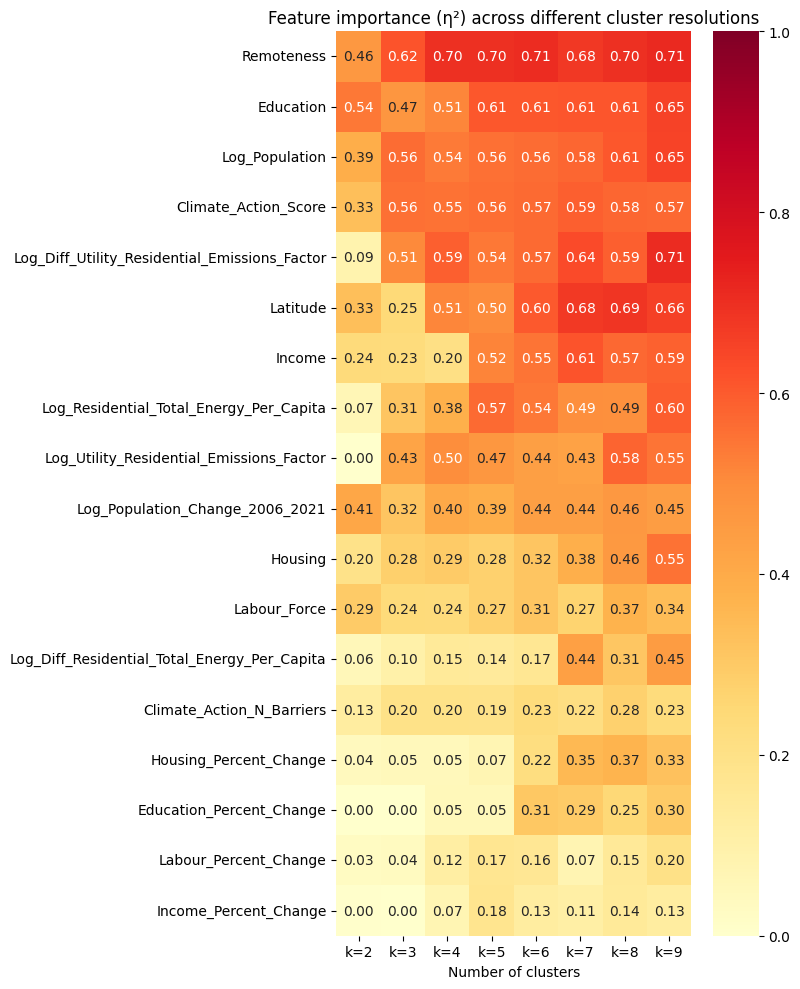


Top features by permutation importance (random forest predicting clusters):


Metric
Log_Population                                   0.0259
Remoteness                                       0.0107
Latitude                                         0.0100
Log_Residential_Total_Energy_Per_Capita          0.0073
Labour_Percent_Change                            0.0045
Log_Utility_Residential_Emissions_Factor         0.0041
Climate_Action_Score                             0.0034
Log_Diff_Utility_Residential_Emissions_Factor    0.0000
Climate_Action_N_Barriers                        0.0000
Log_Population_Change_2006_2021                  0.0000
dtype: float64

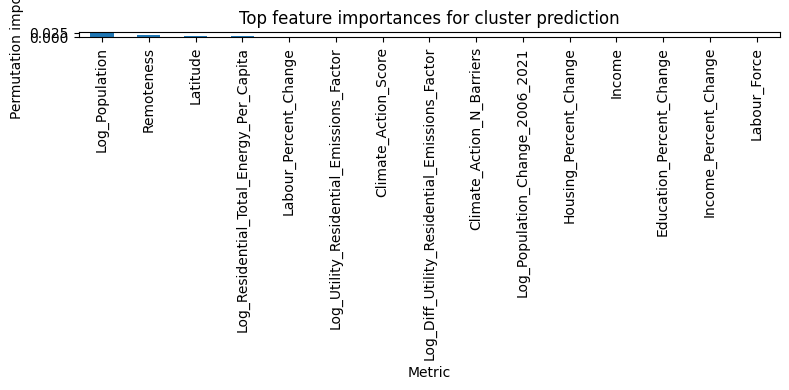


Interpretation hints:
- PCA loadings: large absolute loading = strong contributor to that PC.
- Explained variance: which PCs capture most variance.
- Cluster centroids: show how clusters differ on original features.
- ANOVA F: features with large F differ most across clusters (statistical).
- Permutation RF importance: features that best predict cluster membership (useful for interpretability).


In [100]:
# Eta-squared for each feature across k clusters
def eta_squared(X, labels, col):
    groups = [X[col].values[labels == k] for k in np.unique(labels)]
    grand_mean = X[col].mean()
    
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((X[col].values - grand_mean)**2)
    
    return ss_between / ss_total if ss_total > 0 else 0

effect_sizes = {}
for col in X.columns:
    effect_sizes[col] = eta_squared(X, labels_final, col)

eta_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=['eta_squared']).sort_values('eta_squared', ascending=False)
print("Features ranked by eta-squared (variance explained by clusters):")
display(eta_df.round(3))

import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a dict of labels for different k values
# e.g., all_labels = {2: labels_k2, 3: labels_k3, ..., 7: labels_k7}

eta_matrix = {}
for k, labels in all_labels.items():
    eta_matrix[f'k={k}'] = {col: eta_squared(X, labels, col) for col in X.columns}

eta_heatmap = pd.DataFrame(eta_matrix)

# Sort rows by mean eta-squared across all k
eta_heatmap = eta_heatmap.loc[eta_heatmap.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(8, 10))
sns.heatmap(eta_heatmap, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title('Feature importance (η²) across different cluster resolutions')
plt.xlabel('Number of clusters')
plt.tight_layout()
plt.show()

# Supervised check: how predictive each feature is of the cluster (permutation importance)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
#X_filled = X.fillna(X.median())
#rf.fit(X_filled, labels_final)
rf.fit(X, labels_final)
perm = permutation_importance(rf, X, labels_final, n_repeats=30, random_state=42, n_jobs=-1)
#perm = permutation_importance(rf, X_filled, labels_final, n_repeats=30, random_state=42, n_jobs=-1)
imp_df = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print("\nTop features by permutation importance (random forest predicting clusters):")
display(imp_df.head(10).round(4))

plt.figure(figsize=(8,4))
imp_df.head(15).plot.bar()
plt.ylabel('Permutation importance')
plt.title('Top feature importances for cluster prediction')
plt.tight_layout()
plt.show()

# Guidance:
print("\nInterpretation hints:")
print("- PCA loadings: large absolute loading = strong contributor to that PC.")
print("- Explained variance: which PCs capture most variance.")
print("- Cluster centroids: show how clusters differ on original features.")
print("- ANOVA F: features with large F differ most across clusters (statistical).")
print("- Permutation RF importance: features that best predict cluster membership (useful for interpretability).")


In [96]:
# Create tidy cluster dataframe, attach lat/lon, save and plot on BC map
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

BASE_YEAR = 2021
metric_name = 'cluster_energy_wellbeing'   # change to 'cluster_energy' or other if desired
unit_name = 'cluster_number'

# 1) Build clusters DataFrame (expecting either clusters_df or labels_final + X.index)
if 'clusters_df' in globals():
    clusters_src = clusters_df.reset_index()[['Municipality_Name', 'Cluster']].copy()
else:
    # fall back to labels_final and X.index
    if 'labels_final' in globals() and 'X' in globals():
        clusters_src = pd.DataFrame({
            'Municipality_Name': X.index,
            'Cluster': labels_final
        })
    else:
        raise RuntimeError("No cluster results found. Run the clustering cells first (need `clusters_df` or `labels_final` + `X`).")

clusters_src.head()

,Municipality_Name,Cluster
0,Abbotsford,6
1,Alert Bay,3
2,Anmore,7
3,Armstrong,4
4,Ashcroft,1


In [97]:
#merge cluster numbers with df_wide by matching municiopality names
df_wide = tidy_all_data.pivot_table(
    index='Municipality_Name',
    columns='Metric',
    values='Value',
)

# Add cluster labels (merge clusters_df into df_wide)
df_wide = df_wide.merge(clusters_df, left_index=True, right_index=True, how='left')


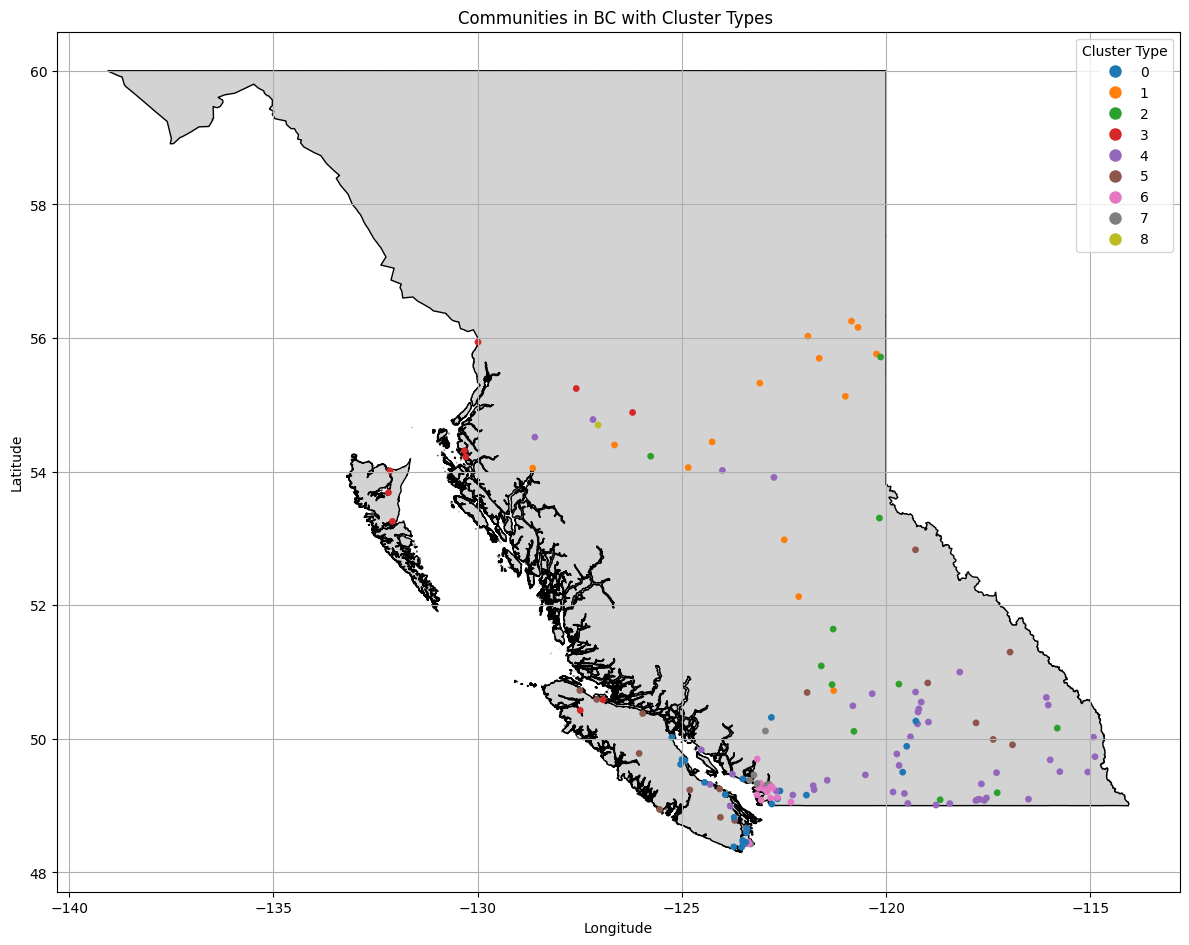

In [98]:
#plot the final analysis data with coordinates on a map of BC, with shapefile located in the raw dataset subfolder BC_Boundary as BC_Boundary.shp
import geopandas as gpd
# Load the shapefile for BC boundaries
bc_boundaries = gpd.read_file(os.path.join('..','..', 'data', 'raw', 'BC_Boundary', 'BC_Boundary.shp'))
# Convert the final analysis data with coordinates to a GeoDataFrame
final_analysis_gdf = gpd.GeoDataFrame(
    df_wide,
    geometry=gpd.points_from_xy(df_wide['Longitude'], df_wide['Latitude']),
    crs='EPSG:4326'  # WGS84 coordinate system
)
"""
cluster_colors = {
    0: 'green',
    1: 'blue',
    2: 'orange',
    3: 'purple',
    4: 'pink',
    5: 'red',
    6: 'black'  
}
"""
# Plot BC base map and clusters (one color per cluster)
clusters = sorted([c for c in df_wide['Cluster'].dropna().unique()])
n_clusters = max(1, len(clusters))
palette = sns.color_palette('tab10', n_colors=max(10, n_clusters))
cluster_colors = {c: palette[i % len(palette)] for i, c in enumerate(clusters)}

final_analysis_gdf['color'] = final_analysis_gdf['Cluster'].map(cluster_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in cluster_colors.items()]
plt.legend(handles=handles, title='Cluster Type', loc='upper right')

plt.title('Communities in BC with Cluster Types ')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

In [99]:
BASE_YEAR = 2021
metric_name = 'cluster_energy_wellbeing'   # change to 'cluster_energy' or other if desired
unit_name = 'cluster_number'
# 2) Save tidy cluster table with Year, Metric, Value, Unit
tiny_cluster = clusters_src.copy()
tiny_cluster['Year'] = BASE_YEAR
tiny_cluster['Metric'] = metric_name
tiny_cluster['Value'] = tiny_cluster['Cluster']   # cluster number as value
tiny_cluster['Unit'] = unit_name
tiny_cluster = tiny_cluster[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]

# 5) Save tidy cluster CSV
out_path = os.path.join('..', '..', 'data', 'processed', f'municipality_clusters_tidy_{metric_name}_{BASE_YEAR}.csv')
tiny_cluster.to_csv(out_path, index=False)
print(f"Saved tidy cluster CSV to: {out_path}")
print("Sample rows:")
display(tiny_cluster.head(10))




Saved tidy cluster CSV to: ../../data/processed/municipality_clusters_tidy_cluster_energy_wellbeing_2021.csv
Sample rows:


,Municipality_Name,Year,Metric,Value,Unit
0,Abbotsford,2021,cluster_energy_wellbeing,6,cluster_number
1,Alert Bay,2021,cluster_energy_wellbeing,3,cluster_number
2,Anmore,2021,cluster_energy_wellbeing,7,cluster_number
3,Armstrong,2021,cluster_energy_wellbeing,4,cluster_number
4,Ashcroft,2021,cluster_energy_wellbeing,1,cluster_number
5,Belcarra,2021,cluster_energy_wellbeing,7,cluster_number
6,Bowen Island,2021,cluster_energy_wellbeing,7,cluster_number
7,Burnaby,2021,cluster_energy_wellbeing,6,cluster_number
8,Burns Lake,2021,cluster_energy_wellbeing,2,cluster_number
9,Cache Creek,2021,cluster_energy_wellbeing,2,cluster_number
